# Pipedrive CRM Data - Exploratory Analysis

This notebook explores the Pipedrive CRM source data to understand structure, relationships, and data quality.

In [25]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# connection using psycopg2
conn = psycopg2.connect(
    host='localhost',
    database='postgres',
    user='admin',
    password='admin',
    port=5432
)

## 1. Data Overview

First, let's check what tables we have and their basic stats.

In [26]:
# get table counts
tables = ['stages', 'activity_types', 'activity', 'deal_changes', 'fields', 'users']

for table in tables:
    query = f"SELECT COUNT(*) as count FROM public.{table}"
    df = pd.read_sql(query, conn)
    print(f"{table}: {df['count'].iloc[0]:,} rows")

AttributeError: 'OptionEngine' object has no attribute 'execute'

## 2. Stages Analysis

Understanding the sales funnel stages.

/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


Sales Funnel Stages:
 stage_id                 stage_name
        1            Lead Generation
        2             Qualified lead
        3           Needs Assessment
        4 Proposal/Quote Preparation
        5                Negotiation
        6                    Closing
        7  Implementation/Onboarding
        8 Follow-up/Customer Success
        9          Renewal/Expansion


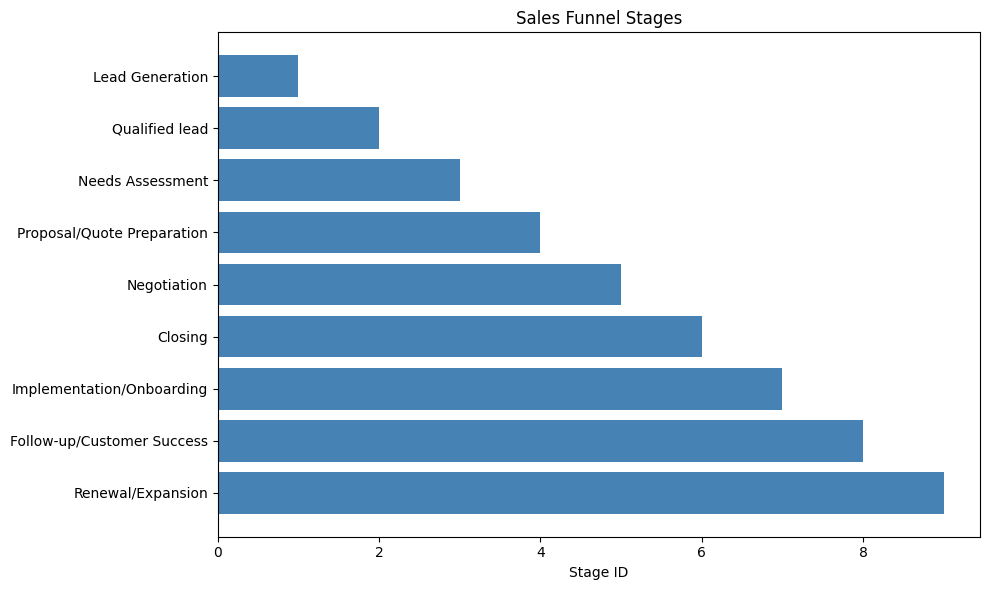

In [4]:
# stages
stages_df = pd.read_sql("SELECT * FROM public.stages ORDER BY stage_id", conn)
print("Sales Funnel Stages:")
print(stages_df.to_string(index=False))

# visualize stages
plt.figure(figsize=(10, 6))
plt.barh(range(len(stages_df)), stages_df['stage_id'], color='steelblue')
plt.yticks(range(len(stages_df)), stages_df['stage_name'])
plt.xlabel('Stage ID')
plt.title('Sales Funnel Stages')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Activity Types

What types of activities are tracked?

In [5]:
# activity types
activity_types_df = pd.read_sql("SELECT * FROM public.activity_types", conn)
print("Activity Types:")
print(activity_types_df.to_string(index=False))

# check which are active
print("\nActive vs Inactive:")
print(activity_types_df['active'].value_counts())

Activity Types:
 id             name active             type
  1     Sales Call 1    Yes          meeting
  2     Sales Call 2    Yes             sc_2
  3   Follow Up Call     No        follow_up
  4 After Close Call    Yes after_close_call

Active vs Inactive:
Yes    3
No     1
Name: active, dtype: int64


/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


## 4. Deal Changes Analysis

This is the key table - tracks all changes to deals over time.

In [6]:
# deal changes overview
deal_changes_df = pd.read_sql("""
    SELECT 
        changed_field_key,
        COUNT(*) as change_count,
        COUNT(DISTINCT deal_id) as unique_deals
    FROM public.deal_changes
    GROUP BY changed_field_key
    ORDER BY change_count DESC
""", conn)

print("Deal Changes by Field:")
print(deal_changes_df.to_string(index=False))

Deal Changes by Field:
changed_field_key  change_count  unique_deals
         stage_id         17812          1995
          user_id          5000          1995
         add_time          4000          1995
      lost_reason          4000          1995


/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


In [7]:
# stage transitions - most important for funnel
stage_changes = pd.read_sql("""
    SELECT 
        changed_field_key,
        new_value as stage_id,
        COUNT(*) as transitions
    FROM public.deal_changes
    WHERE changed_field_key = 'stage_id'
    GROUP BY changed_field_key, new_value
    ORDER BY new_value::integer
""", conn)

print("Stage Transitions:")
print(stage_changes.to_string(index=False))

Stage Transitions:
changed_field_key stage_id  transitions
         stage_id        1         4000
         stage_id        2         2966
         stage_id        3         2616
         stage_id        4         2174
         stage_id        5         1790
         stage_id        6         1482
         stage_id        7         1176
         stage_id        8          958
         stage_id        9          650


/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


In [8]:
# time range of deal changes
time_range = pd.read_sql("""
    SELECT 
        MIN(change_time) as earliest_change,
        MAX(change_time) as latest_change,
        COUNT(DISTINCT deal_id) as total_deals
    FROM public.deal_changes
    WHERE changed_field_key = 'stage_id'
""", conn)

print("Deal Changes Time Range:")
print(time_range.to_string(index=False))

Deal Changes Time Range:
    earliest_change       latest_change  total_deals
2024-01-08 21:07:42 2025-02-24 02:53:13         1995


/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


## 5. Activities Analysis

Understanding activities linked to deals.

In [9]:
# activities overview
activities_df = pd.read_sql("""
    SELECT 
        type,
        COUNT(*) as activity_count,
        COUNT(DISTINCT deal_id) as deals_with_activities,
        COUNT(CASE WHEN done THEN 1 END) as completed_count
    FROM public.activity
    GROUP BY type
    ORDER BY activity_count DESC
""", conn)

print("Activities Summary:")
print(activities_df.to_string(index=False))

Activities Summary:
            type  activity_count  deals_with_activities  completed_count
after_close_call            2354                   1177             1190
         meeting            2290                   1145             1136
       follow_up            2266                   1133             1134
            sc_2            2248                   1123             1120


/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


In [10]:
# activities by type - focus on Sales Call 1 and 2
sales_calls = pd.read_sql("""
    SELECT 
        a.type,
        at.name,
        COUNT(*) as count,
        COUNT(DISTINCT a.deal_id) as unique_deals
    FROM public.activity a
    LEFT JOIN public.activity_types at ON a.type = at.type
    WHERE at.id IN (1, 2)
    GROUP BY a.type, at.name
""", engine)

print("Sales Call Activities:")
print(sales_calls.to_string(index=False))

Sales Call Activities:
   type         name  count  unique_deals
meeting Sales Call 1   2290          1145
   sc_2 Sales Call 2   2248          1123


/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


## 6. Data Relationships

Understanding how tables connect.

In [11]:
# check relationships
print("Key Relationships:\n")

# deals in deal_changes vs activities
deals_in_changes = pd.read_sql("SELECT COUNT(DISTINCT deal_id) as count FROM public.deal_changes WHERE changed_field_key = 'stage_id'", conn)
deals_in_activities = pd.read_sql("SELECT COUNT(DISTINCT deal_id) as count FROM public.activity", conn)

print(f"Unique deals in deal_changes (stage transitions): {deals_in_changes['count'].iloc[0]}")
print(f"Unique deals in activities: {deals_in_activities['count'].iloc[0]}")

# overlap
overlap = pd.read_sql("""
    SELECT COUNT(DISTINCT dc.deal_id) as overlap_count
    FROM public.deal_changes dc
    INNER JOIN public.activity a ON dc.deal_id = a.deal_id
    WHERE dc.changed_field_key = 'stage_id'
""", conn)

print(f"Deals with both stage changes and activities: {overlap['overlap_count'].iloc[0]}")

Key Relationships:

Unique deals in deal_changes (stage transitions): 1995
Unique deals in activities: 4572
Deals with both stage changes and activities: 8


/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


## 7. Data Quality Checks

Checking for data quality issues.

In [12]:
# null checks
print("Null Value Checks:\n")

# deal_changes
nulls_changes = pd.read_sql("""
    SELECT 
        COUNT(*) FILTER (WHERE deal_id IS NULL) as null_deal_id,
        COUNT(*) FILTER (WHERE change_time IS NULL) as null_change_time,
        COUNT(*) FILTER (WHERE changed_field_key IS NULL) as null_field_key
    FROM public.deal_changes
""", conn)
print("deal_changes nulls:")
print(nulls_changes.to_string(index=False))

# activities
nulls_activities = pd.read_sql("""
    SELECT 
        COUNT(*) FILTER (WHERE deal_id IS NULL) as null_deal_id,
        COUNT(*) FILTER (WHERE due_to IS NULL) as null_due_to
    FROM public.activity
""", conn)
print("\nactivity nulls:")
print(nulls_activities.to_string(index=False))

Null Value Checks:

deal_changes nulls:
 null_deal_id  null_change_time  null_field_key
            0                 0               0

activity nulls:
 null_deal_id  null_due_to
            0            0


/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


## 8. Monthly Funnel Distribution

Preview of what the final report will show.

## 9. Dashboard Visualizations

Creating funnel analysis visualizations similar to Power BI dashboards.

In [ ]:
# get final report data for visualization
funnel_data = pd.read_sql("""
    SELECT 
        month,
        kpi_name,
        funnel_step,
        deals_count
    FROM public_pipedrive_analytics.rep_sales_funnel_monthly
    ORDER BY month DESC, funnel_step
""", conn)

print("Funnel Report Data:")
print(funnel_data.head(20).to_string(index=False))

In [ ]:
# funnel visualization - stage by stage conversion
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Funnel chart
latest_month = funnel_data['month'].max()
latest_data = funnel_data[funnel_data['month'] == latest_month].sort_values('funnel_step')

axes[0, 0].barh(latest_data['kpi_name'], latest_data['deals_count'], color='steelblue')
axes[0, 0].set_xlabel('Deals Count')
axes[0, 0].set_title(f'Funnel by Stage - {latest_month.strftime("%B %Y")}')
axes[0, 0].invert_yaxis()

# 2. Monthly trends
monthly_trends = funnel_data.groupby(['month', 'funnel_step'])['deals_count'].sum().reset_index()
pivot_trends = monthly_trends.pivot(index='month', columns='funnel_step', values='deals_count')

axes[0, 1].plot(pivot_trends.index, pivot_trends.values)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Deals Count')
axes[0, 1].set_title('Stage Trends Over Time')
axes[0, 1].legend(pivot_trends.columns, title='Funnel Step', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top performing stages
total_by_stage = funnel_data.groupby('kpi_name')['deals_count'].sum().sort_values(ascending=True)
axes[1, 0].barh(total_by_stage.index, total_by_stage.values, color='coral')
axes[1, 0].set_xlabel('Total Deals')
axes[1, 0].set_title('Top Performing Stages (All Time)')

# 4. Monthly heatmap
heatmap_data = funnel_data.pivot_table(
    index='kpi_name', 
    columns=funnel_data['month'].dt.strftime('%b %Y'), 
    values='deals_count', 
    aggfunc='sum'
)
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='Blues', ax=axes[1, 1], cbar_kws={'label': 'Deals Count'})
axes[1, 1].set_title('Stage Performance Heatmap')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Stage')

plt.tight_layout()
plt.show()

In [ ]:
# conversion rates between stages
conversion_df = pd.read_sql("""
    WITH stage_totals AS (
        SELECT 
            kpi_name,
            funnel_step,
            SUM(deals_count) as total_deals
        FROM public_pipedrive_analytics.rep_sales_funnel_monthly
        GROUP BY kpi_name, funnel_step
    )
    SELECT 
        kpi_name,
        funnel_step,
        total_deals,
        LAG(total_deals) OVER (ORDER BY funnel_step) as previous_stage_deals,
        CASE 
            WHEN LAG(total_deals) OVER (ORDER BY funnel_step) > 0 
            THEN ROUND((total_deals::numeric / LAG(total_deals) OVER (ORDER BY funnel_step)) * 100, 1)
            ELSE NULL
        END as conversion_rate
    FROM stage_totals
    ORDER BY funnel_step
""", conn)

print("Stage Conversion Rates:")
print(conversion_df.to_string(index=False))

In [13]:
# sample monthly distribution
monthly_sample = pd.read_sql("""
    SELECT 
        DATE_TRUNC('month', change_time) as month,
        new_value::integer as stage_id,
        COUNT(DISTINCT deal_id) as deal_count
    FROM public.deal_changes
    WHERE changed_field_key = 'stage_id'
        AND new_value ~ '^[0-9]+$'
    GROUP BY month, new_value::integer
    ORDER BY month DESC, stage_id
    LIMIT 20
""", conn)

print("Sample Monthly Funnel Data:")
print(monthly_sample.to_string(index=False))

Sample Monthly Funnel Data:
     month  stage_id  deal_count
2025-02-01         7           2
2025-02-01         8           2
2025-02-01         9           1
2025-01-01         3           1
2025-01-01         4           2
2025-01-01         5           5
2025-01-01         6          10
2025-01-01         7           9
2025-01-01         8          10
2025-01-01         9          10
2024-12-01         2           3
2024-12-01         3          14
2024-12-01         4          28
2024-12-01         5          28
2024-12-01         6          34
2024-12-01         7          29
2024-12-01         8          20
2024-12-01         9          19
2024-11-01         1          18
2024-11-01         2          49


/opt/homebrew/lib/python3.11/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


## 9. Key Insights

### Findings:

1. **Deal Changes is the primary source** for tracking stage transitions
   - Contains historical changes with timestamps
   - Need to use MIN() to find first entry per stage

2. **Activities table** tracks Sales Call 1 and Sales Call 2
   - Activity type IDs: 1 = Sales Call 1, 2 = Sales Call 2
   - Linked to deals via deal_id

3. **Data structure** supports funnel analysis
   - Stages table provides stage names (1-9)
   - Deal changes track progression
   - Activities provide sub-steps (2.1, 3.1)

4. **Data quality** looks good
   - Minimal nulls in key fields
   - Relationships are consistent

5. **Time range** covers multiple months
   - Supports monthly aggregation
   - Historical data available for trend analysis

In [14]:
print("Analysis complete!")

Analysis complete!
